16,19

In [22]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, fetch_california_housing, load_breast_cancer
from sklearn.metrics import *
import time
import pandas as pd
from sklearn.pipeline import Pipeline

### Zadanie 16

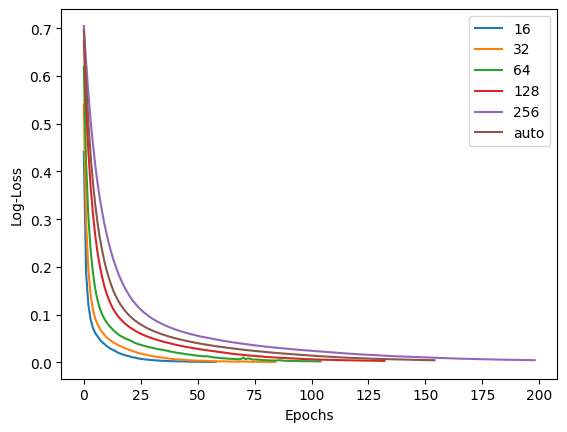

,score,time (s)
16,0.973684,0.408802
32,0.973684,0.328258
64,0.973684,0.252270
128,0.973684,0.195325
256,0.973684,0.201433
auto,0.973684,0.193611


In [19]:
bc = load_breast_cancer()
X, y = bc.data, bc.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
batch_sizes = [16, 32, 64, 128, 256, 'auto']

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scores = {}
for batch in batch_sizes:
    start = time.time()
    mlp_bc = MLPClassifier(solver='adam', hidden_layer_sizes=(64, 32), max_iter=300, batch_size=batch, random_state=42)
    mlp_bc.fit(X_train_scaled, y_train)
    pred = mlp_bc.predict(X_test_scaled)
    score = accuracy_score(y_test, pred)
    stop = time.time()
    scores[batch] = [score, stop - start]
    plt.plot(mlp_bc.loss_curve_,label=f'{batch}')

plt.xlabel('Epochs')
plt.ylabel('Log-Loss')
plt.legend()
plt.show()
df = pd.DataFrame(scores, index=['score', 'time (s)']).transpose()
df

### Zadanie 19

In [31]:
grids = {
    'MLP': {
        'hidden_layer_sizes': [(32,), (64,), (32, 16), (64, 32)],
        'activation': ['relu', 'tanh'],
        'learning_rate_init': [0.001, 0.01],
        'alpha': [0.0001, 0.001, 0.01]
    },
    'RandomForest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 5, 10],
        'min_samples_split': [2, 5]
    }
}

models = {
    'MLP': MLPClassifier(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42)
}

results = {}
for k, v in models.items():
    grid_search = GridSearchCV(v, grids[k], cv=5, n_jobs=-1, scoring='accuracy')
    grid_search.fit(X_train_scaled, y_train)
    results[k] = [grid_search.best_params_, grid_search.best_score_]

df_params = pd.DataFrame([
    {'model': k, **v[0], 'best_score': v[1]}
    for k, v in results.items()])
df_params

,model,activation,alpha,hidden_layer_sizes,learning_rate_init,best_score,max_depth,min_samples_split,n_estimators
0,MLP,relu,0.0001,"(32, 16)",0.001,0.982418,NaN,NaN,NaN
1,RandomForest,NaN,NaN,NaN,NaN,0.962637,NaN,2.0,200.0
